# 🪟 Windowing y Data Leakage en Series Temporales
### Aplicado a FatigueSet (biometría multimodal)

---

## Tabla de contenidos
1. [Setup](#setup)
2. [Qué es windowing](#windowing)
3. [Sliding vs Overlapping](#sliding-overlap)
4. [Leakage por split incorrecto](#leak-split)
5. [Leakage por normalización global](#leak-norm)
6. [Leakage por overlapping](#leak-overlap)
7. [Leakage entre sujetos (LOSO)](#leak-subject)
8. [Checklist final](#checklist)

In [1]:
# ============================================================
# SETUP
# ============================================================
import sys
from pathlib import Path

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'fatigueset-lib').exists() and (p / 'fatigueset').exists()), Path.cwd())
LIB_PATH = (PROJECT_ROOT / 'fatigueset-lib').resolve()
if str(LIB_PATH) not in sys.path:
    sys.path.insert(0, str(LIB_PATH))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

from fatigueset import FatigueSetLoader, convertir_timestamp

BASE_PATH = PROJECT_ROOT / 'fatigueset'
fs_loader = FatigueSetLoader(base_path=BASE_PATH)

WINDOW_SIZE = 100
STEP_NO_OVERLAP = 100
STEP_OVERLAP = 50

PID, SES = '01', '01'

print('✓ Setup completado')
print(f'  Dataset: {BASE_PATH.resolve()}')
print(f'  Ventana: {WINDOW_SIZE} muestras')
print(f'  Step sin overlap: {STEP_NO_OVERLAP} | con overlap: {STEP_OVERLAP}')

✓ Setup completado
  Dataset: C:\Users\egull\OneDrive\Documentos\Proyectos\tfg\fatigueset
  Ventana: 100 muestras
  Step sin overlap: 100 | con overlap: 50


---
<a id='windowing'></a>
# 🧩 ¿Qué es windowing?

Windowing divide una serie temporal en segmentos de longitud fija para convertir una señal continua en muestras aptas para modelado.

Si la señal original es: $[x_1, x_2, ..., x_n]$, con ventanas de tamaño $k$ se obtienen bloques consecutivos.

Cada bloque puede transformarse en features (media, varianza, pendiente, energía, etc.) y usarse como una muestra independiente.

In [2]:
# ============================================================
# Cargar señal real (HR) para una demo visual
# ============================================================
df_hr = fs_loader.cargar_csv(PID, SES, 'chest_physiology_summary.csv')
df_hr = convertir_timestamp(df_hr)

if df_hr is None or 'hr' not in df_hr.columns:
    raise ValueError('No se pudo cargar chest_physiology_summary.csv con columna hr')

serie_hr = df_hr[['datetime', 'hr']].dropna().sort_values('datetime').reset_index(drop=True)

print(f'P{PID}/S{SES} -> {len(serie_hr)} muestras HR')
display(serie_hr.head())

P01/S01 -> 1578 muestras HR


,datetime,hr
0,2021-08-19 10:53:43.437,64
1,2021-08-19 10:53:44.437,62
2,2021-08-19 10:53:45.437,59
3,2021-08-19 10:53:46.437,59
4,2021-08-19 10:53:47.437,59


In [3]:
# ============================================================
# Helper de windowing
# ============================================================
def crear_ventanas(df, col, window_size, step_size):
    x = df[col].to_numpy()
    t = df['datetime'].to_numpy() if 'datetime' in df.columns else np.arange(len(df))

    ventanas = []
    for ini in range(0, len(x) - window_size + 1, step_size):
        fin = ini + window_size
        ventanas.append({
            'ini': ini,
            'fin': fin,
            't_ini': t[ini],
            't_fin': t[fin - 1],
            'values': x[ini:fin]
        })
    return ventanas

def features_basicas(v):
    return {
        'mean': float(np.mean(v)),
        'std': float(np.std(v)),
        'min': float(np.min(v)),
        'max': float(np.max(v)),
        'range': float(np.max(v) - np.min(v))
    }

---
<a id='sliding-overlap'></a>
# 1️⃣ Sliding windows vs 2️⃣ Overlapping windows

- Sin solapamiento: `step_size = window_size`
- Con solapamiento: `step_size < window_size`

El solapamiento aumenta muestras y continuidad temporal, pero puede aumentar el leakage si se divide mal train/test.

Ventanas sin overlap : 15
Ventanas con overlap : 30
Incremento de muestras: 2.00x


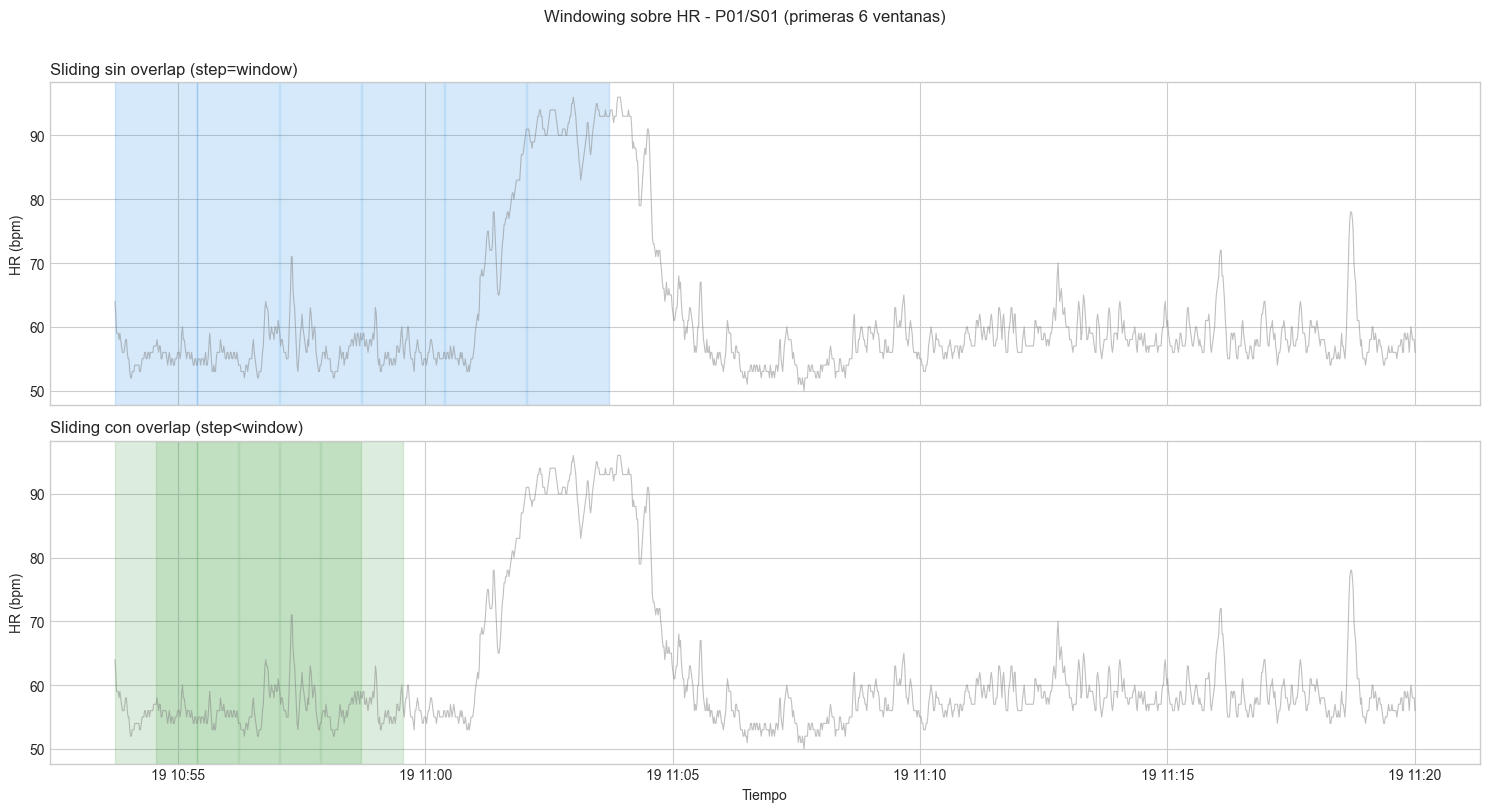

In [4]:
# ============================================================
# Comparación visual: no-overlap vs overlap
# ============================================================
wins_no = crear_ventanas(serie_hr, 'hr', WINDOW_SIZE, STEP_NO_OVERLAP)
wins_ov = crear_ventanas(serie_hr, 'hr', WINDOW_SIZE, STEP_OVERLAP)

print(f'Ventanas sin overlap : {len(wins_no)}')
print(f'Ventanas con overlap : {len(wins_ov)}')
print(f'Incremento de muestras: {len(wins_ov)/max(1, len(wins_no)):.2f}x')

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

for ax, wins, titulo, color in [
    (axes[0], wins_no, 'Sliding sin overlap (step=window)', '#1E88E5'),
    (axes[1], wins_ov, 'Sliding con overlap (step<window)', '#43A047'),
]:
    ax.plot(serie_hr['datetime'], serie_hr['hr'], color='gray', alpha=0.5, linewidth=0.8)
    for w in wins[:6]:
        ax.axvspan(w['t_ini'], w['t_fin'], color=color, alpha=0.18)
    ax.set_title(titulo, loc='left')
    ax.set_ylabel('HR (bpm)')

axes[1].set_xlabel('Tiempo')
plt.suptitle(f'Windowing sobre HR - P{PID}/S{SES} (primeras 6 ventanas)', y=1.01)
plt.tight_layout()
plt.show()

---
<a id='leak-split'></a>
# ⚠️ Leakage 1: split temporal incorrecto

Hacer split aleatorio en datos temporales puede mezclar pasado y futuro entre train/test.

Regla: primero se divide por tiempo o sujeto, y después se hace windowing/normalización/features.

In [5]:
# ============================================================
# Leakage por split aleatorio vs split temporal
# ============================================================
rng = np.random.default_rng(42)
idx = np.arange(len(wins_ov))
rng.shuffle(idx)
cut = int(0.8 * len(idx))
train_rand_idx = idx[:cut]
test_rand_idx = idx[cut:]

# Caso A: split temporal DESPUÉS de ventanear (todavía puede haber leakage por frontera)
wins_sorted = sorted(wins_ov, key=lambda w: w['ini'])
cut_t = int(0.8 * len(wins_sorted))
train_time = wins_sorted[:cut_t]
test_time = wins_sorted[cut_t:]

# Caso B: split temporal ANTES de ventanear (correcto)
cut_raw = int(0.8 * len(serie_hr))
train_raw = serie_hr.iloc[:cut_raw].copy()
test_raw = serie_hr.iloc[cut_raw:].copy()

wins_safe_train = crear_ventanas(train_raw, 'hr', WINDOW_SIZE, STEP_OVERLAP)
wins_safe_test = crear_ventanas(test_raw, 'hr', WINDOW_SIZE, STEP_OVERLAP)

# Pasar a índices globales para poder medir solapamiento real train/test
for w in wins_safe_train:
    w['ini_global'] = w['ini']
    w['fin_global'] = w['fin']
for w in wins_safe_test:
    w['ini_global'] = w['ini'] + cut_raw
    w['fin_global'] = w['fin'] + cut_raw

train_rand_times = np.array([wins_ov[i]['t_ini'] for i in train_rand_idx])
test_rand_times = np.array([wins_ov[i]['t_ini'] for i in test_rand_idx])
frac_future_in_train = (train_rand_times > test_rand_times.min()).mean() if len(test_rand_times) else np.nan

print('Split aleatorio sobre ventanas overlap (incorrecto):')
print(f'  Train: {len(train_rand_idx)} | Test: {len(test_rand_idx)}')
print(f'  % train que empieza después del primer test: {frac_future_in_train*100:.1f}%')

print('\nSplit temporal DESPUÉS de ventanear (riesgo en frontera):')
print(f'  Train: {len(train_time)} | Test: {len(test_time)}')
if test_time:
    print(f'  Última ventana train termina en: {train_time[-1]["t_fin"]}')
    print(f'  Primera ventana test empieza en: {test_time[0]["t_ini"]}')

print('\nSplit temporal ANTES de ventanear (correcto):')
print(f'  Train: {len(wins_safe_train)} | Test: {len(wins_safe_test)}')
if wins_safe_test:
    print(f'  Última ventana train termina en: {wins_safe_train[-1]["t_fin"]}')
    print(f'  Primera ventana test empieza en: {wins_safe_test[0]["t_ini"]}')

Split aleatorio sobre ventanas overlap (incorrecto):
  Train: 24 | Test: 6
  % train que empieza después del primer test: 95.8%

Split temporal DESPUÉS de ventanear (riesgo en frontera):
  Train: 24 | Test: 6
  Última ventana train termina en: 2021-08-19T11:14:32.437000000
  Primera ventana test empieza en: 2021-08-19T11:13:43.437000000

Split temporal ANTES de ventanear (correcto):
  Train: 24 | Test: 5
  Última ventana train termina en: 2021-08-19T11:14:32.437000000
  Primera ventana test empieza en: 2021-08-19T11:14:45.437000000


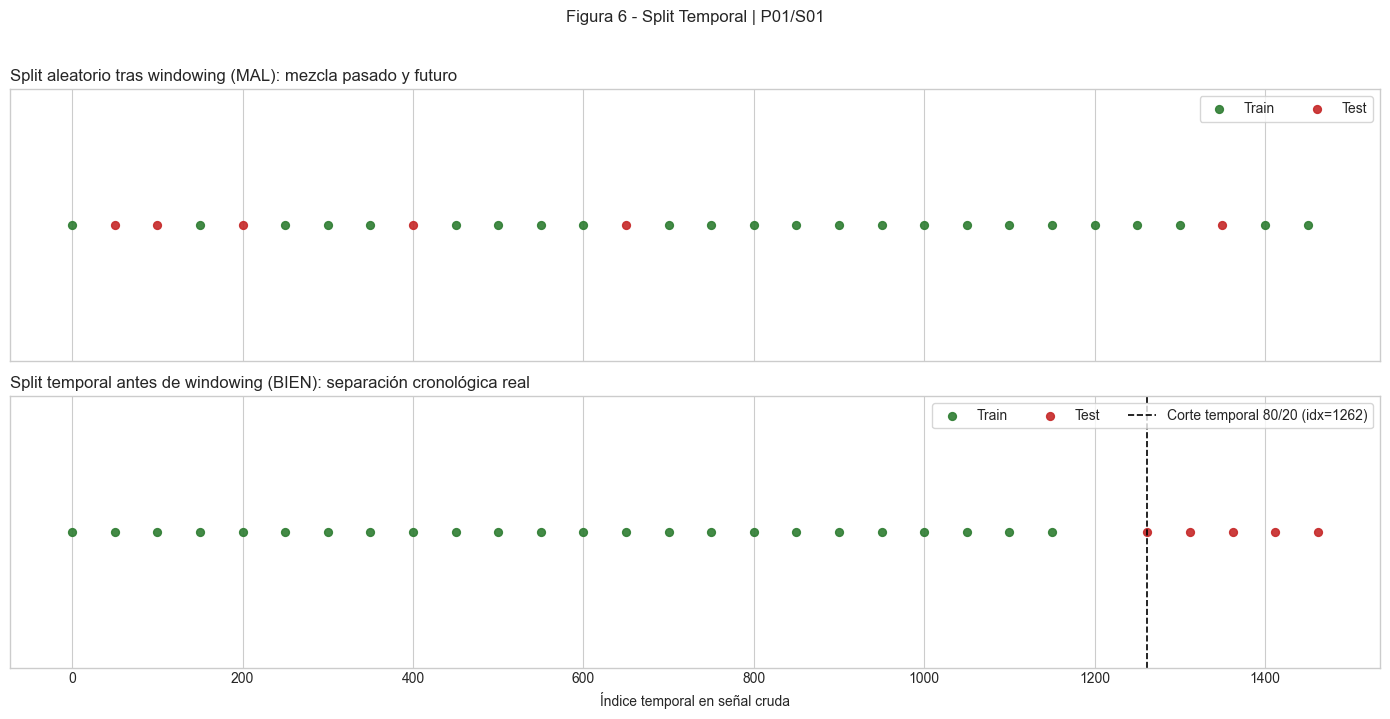

Ventanas total overlap: 30 | Train aleatorio: 24 | Test aleatorio: 6
Ventanas split temporal correcto -> Train: 24 | Test: 5


In [6]:
# ============================================================
# Figura 6: Split aleatorio (MAL) vs split temporal (BIEN)
# ============================================================
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Asegura acceso a la libreria local si se ejecuta esta celda aislada
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'fatigueset-lib').exists() and (p / 'fatigueset').exists()), Path.cwd())
lib_path = (project_root / 'fatigueset-lib').resolve()
if str(lib_path) not in sys.path:
    sys.path.insert(0, str(lib_path))

# Defaults para ejecucion aislada
if 'PID' not in globals():
    PID = '01'
if 'SES' not in globals():
    SES = '01'
if 'WINDOW_SIZE' not in globals():
    WINDOW_SIZE = 100
if 'STEP_OVERLAP' not in globals():
    STEP_OVERLAP = 50

# Helper por si no existe de celdas previas
if 'crear_ventanas' not in globals():
    def crear_ventanas(df, col, window_size, step_size):
        x = df[col].to_numpy()
        t = df['datetime'].to_numpy() if 'datetime' in df.columns else np.arange(len(df))
        ventanas = []
        for ini in range(0, len(x) - window_size + 1, step_size):
            fin = ini + window_size
            ventanas.append({
                'ini': ini,
                'fin': fin,
                't_ini': t[ini],
                't_fin': t[fin - 1],
                'values': x[ini:fin]
            })
        return ventanas

# Carga serie_hr si no viene de celdas anteriores
if 'serie_hr' not in globals():
    from fatigueset import FatigueSetLoader, convertir_timestamp
    BASE_PATH = project_root / 'fatigueset'
    fs_loader = FatigueSetLoader(base_path=BASE_PATH)
    df_hr = fs_loader.cargar_csv(PID, SES, 'chest_physiology_summary.csv')
    df_hr = convertir_timestamp(df_hr)
    if df_hr is None or 'hr' not in df_hr.columns:
        raise ValueError('No se pudo cargar chest_physiology_summary.csv con columna hr')
    serie_hr = df_hr[['datetime', 'hr']].dropna().sort_values('datetime').reset_index(drop=True)

wins_ov = crear_ventanas(serie_hr, 'hr', WINDOW_SIZE, STEP_OVERLAP)
if len(wins_ov) < 8:
    raise ValueError('No hay suficientes ventanas para construir la figura de split temporal')

# MAL: split aleatorio tras windowing
rng = np.random.default_rng(42)
idx = np.arange(len(wins_ov))
rng.shuffle(idx)
cut_w = int(0.8 * len(idx))
train_rand_idx = np.sort(idx[:cut_w])
test_rand_idx = np.sort(idx[cut_w:])
starts_rand_train = np.array([wins_ov[i]['ini'] for i in train_rand_idx])
starts_rand_test = np.array([wins_ov[i]['ini'] for i in test_rand_idx])

# BIEN: split temporal antes de windowing
cut_raw = int(0.8 * len(serie_hr))
train_raw = serie_hr.iloc[:cut_raw].copy()
test_raw = serie_hr.iloc[cut_raw:].copy()
wins_safe_train = crear_ventanas(train_raw, 'hr', WINDOW_SIZE, STEP_OVERLAP)
wins_safe_test = crear_ventanas(test_raw, 'hr', WINDOW_SIZE, STEP_OVERLAP)
starts_safe_train = np.array([w['ini'] for w in wins_safe_train])
starts_safe_test = np.array([w['ini'] + cut_raw for w in wins_safe_test])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Panel superior: aleatorio (MAL)
axes[0].scatter(starts_rand_train, np.ones_like(starts_rand_train), s=32, color='#2E7D32', alpha=0.9, label='Train')
axes[0].scatter(starts_rand_test, np.ones_like(starts_rand_test), s=32, color='#C62828', alpha=0.9, label='Test')
axes[0].set_yticks([])
axes[0].set_title('Split aleatorio tras windowing (MAL): mezcla pasado y futuro', loc='left')
axes[0].legend(frameon=True, ncol=2, loc='upper right')

# Panel inferior: temporal (BIEN)
axes[1].scatter(starts_safe_train, np.ones_like(starts_safe_train), s=32, color='#2E7D32', alpha=0.9, label='Train')
axes[1].scatter(starts_safe_test, np.ones_like(starts_safe_test), s=32, color='#C62828', alpha=0.9, label='Test')
axes[1].axvline(cut_raw, color='black', linestyle='--', linewidth=1.2, label=f'Corte temporal 80/20 (idx={cut_raw})')
axes[1].set_yticks([])
axes[1].set_title('Split temporal antes de windowing (BIEN): separación cronológica real', loc='left')
axes[1].set_xlabel('Índice temporal en señal cruda')
axes[1].legend(frameon=True, ncol=3, loc='upper right')

plt.suptitle(f'Figura 6 - Split Temporal | P{PID}/S{SES}', y=1.02)
plt.tight_layout()
plt.show()

print(f'Ventanas total overlap: {len(wins_ov)} | Train aleatorio: {len(train_rand_idx)} | Test aleatorio: {len(test_rand_idx)}')
print(f'Ventanas split temporal correcto -> Train: {len(wins_safe_train)} | Test: {len(wins_safe_test)}')

---
<a id='leak-norm'></a>
# ⚠️ Leakage 2: normalización global

Si calculas media y desviación con train+test, ya estás inyectando información del test en el pipeline.

Correcto: ajustar estadísticas solo con train y aplicar a test.

In [7]:
# ============================================================
# Global (incorrecto) vs train-only (correcto)
# ============================================================
def ventanas_a_df_features(ventanas):
    rows = []
    for w in ventanas:
        f = features_basicas(w['values'])
        f.update({'t_ini': w['t_ini'], 't_fin': w['t_fin']})
        rows.append(f)
    return pd.DataFrame(rows)

df_feat = ventanas_a_df_features(wins_sorted)
cut_feat = int(0.8 * len(df_feat))
df_train = df_feat.iloc[:cut_feat].copy()
df_test = df_feat.iloc[cut_feat:].copy()
cols_feat = ['mean', 'std', 'min', 'max', 'range']

mu_all = df_feat[cols_feat].mean()
sd_all = df_feat[cols_feat].std().replace(0, 1)
test_z_global = (df_test[cols_feat] - mu_all) / sd_all

mu_tr = df_train[cols_feat].mean()
sd_tr = df_train[cols_feat].std().replace(0, 1)
test_z_train = (df_test[cols_feat] - mu_tr) / sd_tr

diff = (test_z_global - test_z_train).abs().mean().sort_values(ascending=False)
print('Diferencia media absoluta en test (global vs train-only):')
display(diff.to_frame('abs_diff_promedio').round(4))

Diferencia media absoluta en test (global vs train-only):


,abs_diff_promedio
max,0.0387
std,0.0360
mean,0.0348
range,0.0332
min,0.0125


---
<a id='leak-overlap'></a>
# ⚠️ Leakage 3: overlapping + split aleatorio

Con overlap alto, ventanas consecutivas son muy similares. Si el split es aleatorio, train y test comparten casi la misma información.

In [8]:
# ============================================================
# Similaridad train-test: random vs temporal
# ============================================================
def cosine_sim(a, b):
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))

train_rand_w = [wins_ov[i] for i in train_rand_idx]
test_rand_w = [wins_ov[i] for i in test_rand_idx]

# Split temporal hecho después de ventanear (todavía contaminable en frontera)
train_temp_post_w = train_time
test_temp_post_w = test_time

# Split temporal correcto: primero dividir señal, luego ventanear cada bloque
train_temp_safe_w = wins_safe_train
test_temp_safe_w = wins_safe_test

def avg_best_similarity(train_list, test_list, sample_test=40):
    if len(train_list) == 0 or len(test_list) == 0:
        return np.nan
    sims = []
    for tw in test_list[:min(sample_test, len(test_list))]:
        tv = tw['values']
        sims.append(max(cosine_sim(tv, tr['values']) for tr in train_list))
    return float(np.mean(sims))

def overlap_ratio(a_ini, a_fin, b_ini, b_fin):
    inter = max(0, min(a_fin, b_fin) - max(a_ini, b_ini))
    base = max(1, a_fin - a_ini)
    return inter / base

def avg_max_overlap(train_list, test_list, use_global=False):
    if len(train_list) == 0 or len(test_list) == 0:
        return np.nan
    vals = []
    for tw in test_list:
        if use_global:
            t_ini, t_fin = tw['ini_global'], tw['fin_global']
            best = max(overlap_ratio(t_ini, t_fin, tr['ini_global'], tr['fin_global']) for tr in train_list)
        else:
            t_ini, t_fin = tw['ini'], tw['fin']
            best = max(overlap_ratio(t_ini, t_fin, tr['ini'], tr['fin']) for tr in train_list)
        vals.append(best)
    return float(np.mean(vals))

# Garantiza índices globales si se reejecuta esta celda de forma aislada
if train_temp_safe_w and 'ini_global' not in train_temp_safe_w[0]:
    for tr in train_temp_safe_w:
        tr['ini_global'] = tr['ini']
        tr['fin_global'] = tr['fin']

if test_temp_safe_w and 'ini_global' not in test_temp_safe_w[0]:
    offset = cut_raw if 'cut_raw' in globals() else 0
    for tw in test_temp_safe_w:
        tw['ini_global'] = tw['ini'] + offset
        tw['fin_global'] = tw['fin'] + offset

sim_rand = avg_best_similarity(train_rand_w, test_rand_w)
sim_post = avg_best_similarity(train_temp_post_w, test_temp_post_w)
sim_safe = avg_best_similarity(train_temp_safe_w, test_temp_safe_w)

ov_rand = avg_max_overlap(train_rand_w, test_rand_w, use_global=False)
ov_post = avg_max_overlap(train_temp_post_w, test_temp_post_w, use_global=False)
ov_safe = avg_max_overlap(train_temp_safe_w, test_temp_safe_w, use_global=True)

print(f'Similitud máxima media test->train (split aleatorio):            {sim_rand:.4f}')
print(f'Similitud máxima media test->train (split temporal post-window):  {sim_post:.4f}')
print(f'Similitud máxima media test->train (split temporal correcto):     {sim_safe:.4f}')
print()
print(f'Solapamiento medio máximo de índices (aleatorio):                 {ov_rand:.3f}')
print(f'Solapamiento medio máximo de índices (post-window):               {ov_post:.3f}')
print(f'Solapamiento medio máximo de índices (correcto):                  {ov_safe:.3f}')

print('\nEl escenario correcto debe llevar solapamiento ~0 entre train y test.')

Similitud máxima media test->train (split aleatorio):            0.9979
Similitud máxima media test->train (split temporal post-window):  0.9983
Similitud máxima media test->train (split temporal correcto):     0.9979

Solapamiento medio máximo de índices (aleatorio):                 0.500
Solapamiento medio máximo de índices (post-window):               0.083
Solapamiento medio máximo de índices (correcto):                  0.000

El escenario correcto debe llevar solapamiento ~0 entre train y test.


---
<a id='leak-subject'></a>
# ⚠️ Leakage 4: entre sujetos + mini LOSO

En biometría, si el mismo sujeto aparece en train y test, el modelo aprende identidad en lugar de estado fisiológico.

Pipeline correcto: split por sujeto y normalización con estadísticas solo de train.

In [9]:
# ============================================================
# Mini LOSO sin leakage de normalización
# ============================================================
project_root = globals().get(
    'PROJECT_ROOT',
    next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'fatigueset').exists()), Path.cwd())
)
ml_path = project_root / 'fatigueset_aggregated_features.csv'
if not ml_path.exists():
    raise FileNotFoundError(f'No existe {ml_path}')

df_ml = pd.read_csv(ml_path)
if 'participante' not in df_ml.columns:
    raise ValueError('Falta columna participante en el dataset agregado')

cols_num = [c for c in ['hr_media', 'eda_media', 'hrv_media'] if c in df_ml.columns]
res_loso = []

for pid_test in sorted(df_ml['participante'].astype(str).unique()):
    train = df_ml[df_ml['participante'].astype(str) != pid_test]
    test = df_ml[df_ml['participante'].astype(str) == pid_test]

    mu = train[cols_num].mean()
    sd = train[cols_num].std().replace(0, 1)

    test_z = (test[cols_num] - mu) / sd
    drift = test_z.mean().abs().mean()

    res_loso.append({
        'pid_test': pid_test,
        'n_train': len(train),
        'n_test': len(test),
        'drift_abs_mean_test': float(drift)
    })

df_loso = pd.DataFrame(res_loso).set_index('pid_test')
print('Simulación LOSO sin leakage de normalización:')
display(df_loso.round(4))

Simulación LOSO sin leakage de normalización:


,n_train,n_test,drift_abs_mean_test
pid_test,,,
1,99,9,0.5869
10,99,9,0.5994
11,99,9,1.1921
12,99,9,0.2018
2,99,9,0.1226
3,99,9,0.5045
4,99,9,0.4045
5,99,9,0.4613
6,99,9,0.4610


---
<a id='checklist'></a>
# Checklist anti-leakage

1. Split primero (por tiempo/sujeto), luego windowing.
2. Normalización ajustada solo con train.
3. Evitar overlap entre train/test cuando hay sliding windows muy correlacionadas.
4. Revisar que ninguna feature mire al futuro.
5. En biometría, priorizar validación LOSO para evitar aprender identidad.

Si baja la métrica al corregir leakage, no es fracaso: es validez experimental.